In [1]:
import pandas as pd
dataset = pd.read_csv("Social_Network_Ads.csv")

In [2]:
dataset.head(2)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0


In [3]:
dataset = dataset.drop(columns=(['User ID']))

In [4]:
dataset.head(2)

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0


In [5]:
dataset = pd.get_dummies(dataset, dtype=int, drop_first=True)

In [6]:
dataset.head(2)

,Age,EstimatedSalary,Purchased,Gender_Male
0,19,19000,0,1
1,35,20000,0,1


In [7]:
dataset.columns

Index(['Age', 'EstimatedSalary', 'Purchased', 'Gender_Male'], dtype='object')

In [8]:
independent=dataset[['Age', 'EstimatedSalary','Gender_Male']]
dependent=dataset[['Purchased']]

In [9]:
dependent.value_counts()

Purchased
0            257
1            143
Name: count, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(independent, dependent, test_size=1/3, random_state=0)

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [12]:
X_train=sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [15]:
from sklearn.tree import DecisionTreeClassifier

In [16]:
from sklearn.model_selection import GridSearchCV

In [17]:
param_grid = {'criterion':['gini', 'entropy'],
              'max_features':['sqrt', 'auto','log2'], 
              'splitter':['best','random']}

In [18]:
grid = GridSearchCV(DecisionTreeClassifier(), param_grid, refit=True, verbose=3, n_jobs=-1, scoring='f1_weighted')

In [19]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_features': ['sqrt', 'auto', ...], 'splitter': ['best', 'random']}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [21]:
re=grid.cv_results_

In [22]:
grid_pred = grid.predict(X_test)

In [23]:
from sklearn.metrics import confusion_matrix, classification_report

In [24]:
cm=confusion_matrix(y_test, grid_pred)
print(cm)

[[77  8]
 [ 6 43]]


In [25]:
clf=classification_report(y_test,grid_pred)
print(clf)

              precision    recall  f1-score   support

           0       0.93      0.91      0.92        85
           1       0.84      0.88      0.86        49

    accuracy                           0.90       134
   macro avg       0.89      0.89      0.89       134
weighted avg       0.90      0.90      0.90       134



In [26]:
print("The best grid parameter is {}".format(grid.best_params_))

The best grid parameter is {'criterion': 'gini', 'max_features': 'log2', 'splitter': 'best'}


In [27]:
from sklearn.metrics import f1_score
f1_macro = f1_score(y_test,grid_pred,average='weighted')
print("The F1 value for the best grid parameter is {}".format(grid.best_params_), f1_macro)

The F1 value for the best grid parameter is {'criterion': 'gini', 'max_features': 'log2', 'splitter': 'best'} 0.8959452736318407


In [28]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, grid.predict_proba(X_test)[:,1])

0.8917166866746699

In [29]:
import matplotlib.pyplot as plt
from sklearn import metrics

In [30]:
y_pred_proba= grid.predict_proba(X_test)[:,1]

In [31]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)

In [32]:
roc_auc = metrics.roc_auc_score(y_test, y_pred_proba)

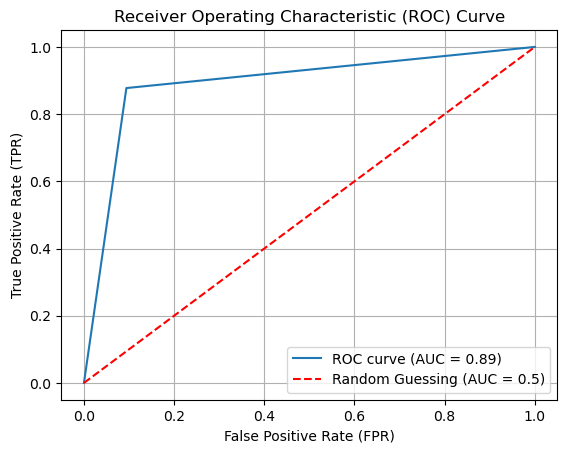

In [33]:
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guessing (AUC = 0.5)') # Diagonal baseline
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [34]:
table = pd.DataFrame.from_dict(re)

In [35]:
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_features,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.011422,0.003669,0.025682,0.004332,gini,sqrt,best,"{'criterion': 'gini', 'max_features': 'sqrt', ...",0.829615,0.795789,0.796687,0.867097,0.844370,0.826712,0.027600,6
1,0.011652,0.002628,0.026942,0.005699,gini,sqrt,random,"{'criterion': 'gini', 'max_features': 'sqrt', ...",0.804764,0.735849,0.796284,0.773585,0.885265,0.799149,0.049226,8
2,0.001627,0.000880,0.000000,0.000000,gini,auto,best,"{'criterion': 'gini', 'max_features': 'auto', ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
3,0.002217,0.000944,0.000000,0.000000,gini,auto,random,"{'criterion': 'gini', 'max_features': 'auto', ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
4,0.007877,0.001789,0.024976,0.001999,gini,log2,best,"{'criterion': 'gini', 'max_features': 'log2', ...",0.826263,0.828959,0.851527,0.869709,0.943041,0.863900,0.042633,1
5,0.006982,0.001522,0.018264,0.001623,gini,log2,random,"{'criterion': 'gini', 'max_features': 'log2', ...",0.843811,0.770070,0.832483,0.852044,0.865054,0.832693,0.033067,5
6,0.006180,0.002283,0.026051,0.003965,entropy,sqrt,best,"{'criterion': 'entropy', 'max_features': 'sqrt...",0.829615,0.886792,0.813179,0.850543,0.886792,0.853384,0.029738,2
7,0.008450,0.001700,0.029135,0.003761,entropy,sqrt,random,"{'criterion': 'entropy', 'max_features': 'sqrt...",0.808927,0.888107,0.795256,0.844370,0.922185,0.851769,0.047671,3
8,0.002443,0.000813,0.000000,0.000000,entropy,auto,best,"{'criterion': 'entropy', 'max_features': 'auto...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
9,0.001741,0.000757,0.000000,0.000000,entropy,auto,random,"{'criterion': 'entropy', 'max_features': 'auto...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
